# Risk Predictor Training Demo
This notebook is aligned with runtime deployment: seq2seq model, 16-frame window, 12-frame burn-in, and 4-frame prediction.
It keeps DataLoader throughput settings (`num_workers`, `prefetch_factor`, `persistent_workers`) for stable multi-epoch training.

In [1]:
import torch
from torchvision import transforms

from MIREIA.config import Config
from MIREIA.perception.e2e_model import E2EModelConfig, E2ERiskPredictor, Seq2SeqRiskPredictor
from MIREIA.perception.training_utils import (
    build_scenario_dataloaders,
    load_checkpoint,
    save_checkpoint,
    train_model,
 )

In [2]:
# Runtime-aligned training setup (matches streaming inference path).
import os

model_type = "seq2seq"  # use seq2seq for FIFO temporal deployment
m_eval_frames = Config.INFERENCE_EVAL_FRAMES  # expected: 4
seq_len = Config.INFERENCE_SEQUENCE_LENGTH  # expected: 16
burn_in_frames = Config.INFERENCE_BURN_IN_FRAMES  # expected: 12
if burn_in_frames + m_eval_frames != seq_len:
    raise ValueError(
        f"Invalid temporal setup: burn_in({burn_in_frames}) + eval({m_eval_frames}) != seq_len({seq_len})"
    )

# Throughput-focused defaults (adjust if you hit OOM).
batch_size = 10  # was 2; increase to better saturate GPU
num_workers = 4
prefetch_factor = 4  # batches prefetched per worker
pin_memory = False
persistent_workers = True  # keep workers alive across epochs for throughput

window_subset_ratio = 0.01  # set None for full dataset
window_subset_mode = "random"  # "random" or "first"
window_subset_seed = Config.RANDOM_SEED

# Reuse the default dataset transform
transform = transforms.Compose(
    [
        transforms.Resize((512, 512)),
        transforms.ToTensor(),
    ]
)

train_loader, val_loader, target_mode = build_scenario_dataloaders(
    seq_len=seq_len,
    batch_size=batch_size,
    num_workers=num_workers,
    prefetch_factor=prefetch_factor,
    pin_memory=pin_memory,
    persistent_workers=persistent_workers,
    transform=transform,
    model_type=model_type,
    m_eval_frames=m_eval_frames,
    window_subset_ratio=window_subset_ratio,
    window_subset_mode=window_subset_mode,
    window_subset_seed=window_subset_seed,
 )

print(f"Temporal config: seq_len={seq_len}, burn_in={burn_in_frames}, eval={m_eval_frames}")
print(f"DataLoader workers: num_workers={num_workers}, prefetch_factor={prefetch_factor}, persistent_workers={persistent_workers}")
print(f"Train batches: {len(train_loader)}")
print(f"Val batches: {len(val_loader)}")


Temporal config: seq_len=16, burn_in=12, eval=4
DataLoader workers: num_workers=4, prefetch_factor=4, persistent_workers=True
Train batches: 137
Val batches: 22


In [3]:
batch_x, batch_y = next(iter(train_loader))
print("Batch X shape:", batch_x.shape)
print("Batch Y shape:", batch_y.shape)
print("Batch X dtype:", batch_x.dtype)
print("Batch Y dtype:", batch_y.dtype)

Batch X shape: torch.Size([10, 16, 3, 512, 512])
Batch Y shape: torch.Size([10, 16, 1])
Batch X dtype: torch.float32
Batch Y dtype: torch.float32


In [4]:
import torch
from torch import nn, optim

if not torch.cuda.is_available():
    raise RuntimeError("CUDA is not available. Install a CUDA-enabled PyTorch build or check your GPU drivers.")

import torch._dynamo
torch._dynamo.config.suppress_errors = True

torch.backends.cudnn.benchmark = True
torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32 = True
torch.set_float32_matmul_precision("high")

device = torch.device("cuda")
print(f"Using GPU: {torch.cuda.get_device_name(0)}")

if model_type == "seq2seq":
    model = Seq2SeqRiskPredictor(E2EModelConfig()).to(device)
else:
    model = E2ERiskPredictor(E2EModelConfig()).to(device)

# Memory format optimization for CNN-heavy workloads
model = model.to(memory_format=torch.channels_last)

# torch.compile can improve throughput on long runs (PyTorch 2.x).
"""if hasattr(torch, "compile"):
    try:
        model = torch.compile(model)
        print("torch.compile enabled")
    except Exception as exc:
        print(f"torch.compile skipped: {exc}")"""

optimizer = optim.Adam(model.parameters(), lr=1e-4)
criterion = nn.MSELoss()
grad_clip = None

# Additional compute optimizations in training loop
use_amp = True  # mixed precision (Tensor Cores)

epochs = 1
log_every = 10
max_batches_per_epoch = None  # set to an int to cap batches for quicker tests
print(f"Starting training for {epochs} epochs on {device}...")
print(f"AMP enabled: {use_amp}")

history = train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    optimizer=optimizer,
    device=device,
    criterion=criterion,
    epochs=epochs,
    log_every=log_every,
    max_batches_per_epoch=max_batches_per_epoch,
    model_type=model_type,
    m_eval_frames=m_eval_frames,
    grad_clip=grad_clip,
    use_amp=use_amp,
 )

print("\nTraining complete.")
print(history)

Using GPU: NVIDIA GeForce RTX 4080 SUPER
Starting training for 1 epochs on cuda...
AMP enabled: True


d:\Projectes\TFG\MIREIA\perception\training_utils.py:104: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=amp_enabled)


Batch 1/137 | avg loss: 12.247504 | batch shape: (10, 16, 3, 512, 512) | ETA: 702.1s (11.7m)
Batch 10/137 | avg loss: 10.658133 | batch shape: (10, 16, 3, 512, 512) | ETA: 260.1s (4.3m)
Batch 20/137 | avg loss: 10.042466 | batch shape: (10, 16, 3, 512, 512) | ETA: 219.6s (3.7m)
Batch 30/137 | avg loss: 8.765453 | batch shape: (10, 16, 3, 512, 512) | ETA: 194.3s (3.2m)
Batch 40/137 | avg loss: 8.681269 | batch shape: (10, 16, 3, 512, 512) | ETA: 172.4s (2.9m)
Batch 50/137 | avg loss: 8.093316 | batch shape: (10, 16, 3, 512, 512) | ETA: 152.8s (2.5m)
Batch 60/137 | avg loss: 7.300712 | batch shape: (10, 16, 3, 512, 512) | ETA: 134.5s (2.2m)
Batch 70/137 | avg loss: 7.880944 | batch shape: (10, 16, 3, 512, 512) | ETA: 116.6s (1.9m)
Batch 80/137 | avg loss: 7.576244 | batch shape: (10, 16, 3, 512, 512) | ETA: 98.9s (1.6m)
Batch 90/137 | avg loss: 7.348515 | batch shape: (10, 16, 3, 512, 512) | ETA: 81.3s (1.4m)
Batch 100/137 | avg loss: 7.221646 | batch shape: (10, 16, 3, 512, 512) | ETA: 

In [5]:
import os

checkpoint_name = "seq2seq_risk_checkpoint.pt" if model_type == "seq2seq" else "single_checkpoint.pt"
checkpoint_path = os.path.join(
    Config.PATH_TO_MODELS,
    checkpoint_name,
)

# Keep these in checkpoint metadata for reproducible resume/deployment.
use_amp_meta = use_amp if "use_amp" in globals() else False

save_checkpoint(
    checkpoint_path=checkpoint_path,
    model=model,
    optimizer=optimizer,
    history=history,
    epoch=epochs,
    extra={
        "model_type": model_type,
        "m_eval_frames": m_eval_frames,
        "seq_len": seq_len,
        "target_mode": target_mode,
        "use_amp": use_amp_meta,
    },
)
print(f"Checkpoint saved to {checkpoint_path}")

Checkpoint saved to d:\Projectes\TFG\MIREIA\models\seq2seq_risk_checkpoint.pt


In [6]:
# Resume training from checkpoint if available
import os
import torch
from torch import nn, optim

resume_epochs = 1  # number of epochs to train after resuming

if not torch.cuda.is_available():
    raise RuntimeError("CUDA is not available. Install a CUDA-enabled PyTorch build or check your GPU drivers.")

device = torch.device("cuda")
if model_type == "seq2seq":
    model = Seq2SeqRiskPredictor(E2EModelConfig()).to(device)
else:
    model = E2ERiskPredictor(E2EModelConfig()).to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-4)
criterion = nn.MSELoss()

# Keep resume path aligned with initial save cell
if "checkpoint_path" not in globals():
    checkpoint_name = "seq2seq_risk_checkpoint.pt" if model_type == "seq2seq" else "single_checkpoint.pt"
    checkpoint_path = os.path.join(Config.PATH_TO_MODELS, checkpoint_name)

use_amp = True

start_epoch = 1
history = {"train_loss": [], "val_loss": []}
if os.path.exists(checkpoint_path):
    ckpt = load_checkpoint(checkpoint_path, model, optimizer=optimizer, device=device)
    history = ckpt.get("history", history)
    start_epoch = ckpt.get("epoch", 0) + 1
    model_type = ckpt.get("model_type", model_type)
    m_eval_frames = ckpt.get("m_eval_frames", m_eval_frames)
    print(f"Resuming from {checkpoint_path} at epoch {start_epoch}")
else:
    print("No checkpoint found. Starting fresh.")

history = train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    optimizer=optimizer,
    device=device,
    criterion=criterion,
    epochs=resume_epochs,
    start_epoch=start_epoch,
    history=history,
    model_type=model_type,
    m_eval_frames=m_eval_frames,
    use_amp=use_amp,
 )

save_checkpoint(
    checkpoint_path=checkpoint_path,
    model=model,
    optimizer=optimizer,
    history=history,
    epoch=start_epoch + resume_epochs - 1,
    extra={
        "model_type": model_type,
        "m_eval_frames": m_eval_frames,
        "seq_len": seq_len,
        "target_mode": target_mode,
        "use_amp": use_amp,
    },
)
print(f"Saved checkpoint: {checkpoint_path}")

d:\Projectes\TFG\MIREIA\perception\training_utils.py:270: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state = torch.load(checkpoint_path, map_location=device)


Resuming from d:\Projectes\TFG\MIREIA\models\seq2seq_risk_checkpoint.pt at epoch 2
Batch 1/137 | avg loss: 1.038665 | batch shape: (10, 16, 3, 512, 512) | ETA: 677.0s (11.3m)


KeyboardInterrupt: 

In [7]:
# Summary metrics (run after training)
train_samples = len(train_loader.dataset)
val_samples = len(val_loader.dataset) if val_loader is not None else 0
print(f"Train samples: {train_samples}")
print(f"Val samples:   {val_samples}")
print(f"Train batches: {len(train_loader)}")
print(f"Val batches:   {len(val_loader)}")

if "history" in globals() and history.get("train_loss"):
    best_train = min(history["train_loss"])
    print(f"Best train loss: {best_train:.6f}")
if "history" in globals() and history.get("val_loss"):
    best_val = min(history["val_loss"])
    print(f"Best val loss:   {best_val:.6f}")

if torch.cuda.is_available():
    mem_alloc = torch.cuda.max_memory_allocated() / (1024 ** 3)
    mem_reserved = torch.cuda.max_memory_reserved() / (1024 ** 3)
    print(f"Peak CUDA allocated: {mem_alloc:.2f} GB")
    print(f"Peak CUDA reserved:  {mem_reserved:.2f} GB")

Train samples: 1363
Val samples:   215
Train batches: 137
Val batches:   22
Best train loss: 6.441666
Best val loss:   8.528739
Peak CUDA allocated: 11.76 GB
Peak CUDA reserved:  14.21 GB


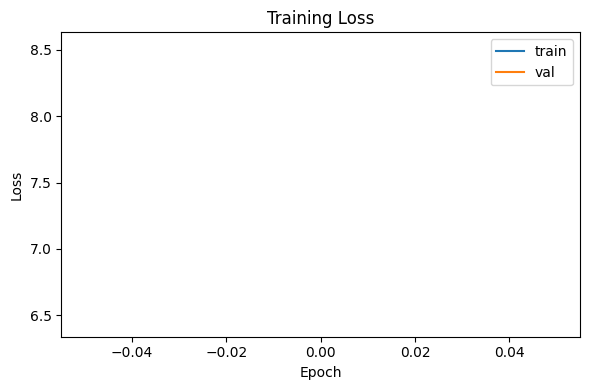

In [8]:
import matplotlib.pyplot as plt

if "history" in globals() and history.get("train_loss"):
    plt.figure(figsize=(6, 4))
    plt.plot(history["train_loss"], label="train")
    if history.get("val_loss"):
        plt.plot(history["val_loss"], label="val")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Training Loss")
    plt.legend()
    plt.tight_layout()
    plt.show()
else:
    print("No training history found. Run the training cell first.")

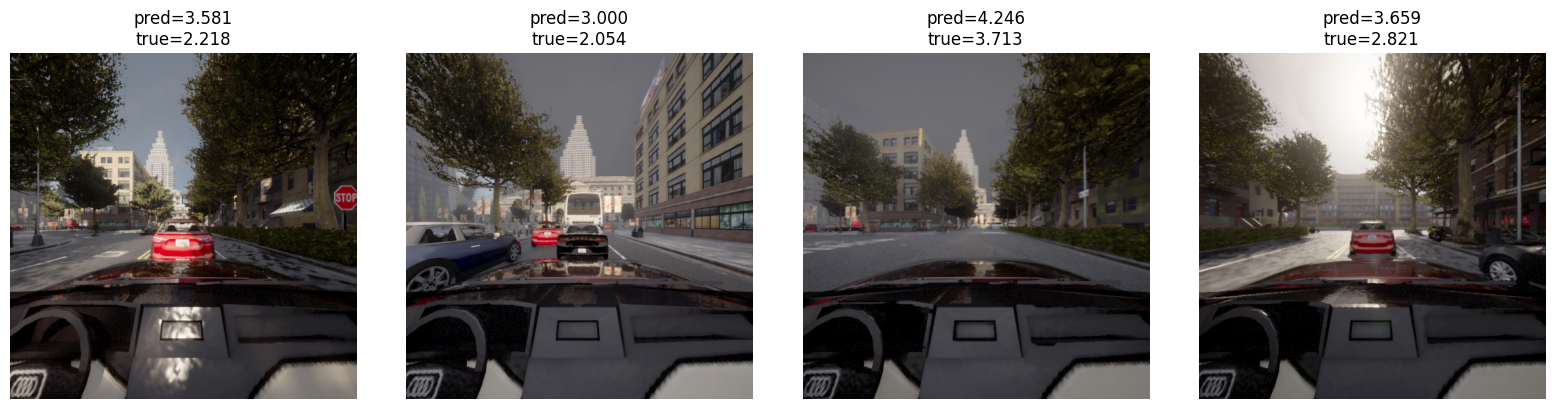

In [9]:
import matplotlib.pyplot as plt
import torch
import random

if "model" not in globals():
    print("Model not found. Run the training cell first.")
else:
    model.eval()
    dataset = val_loader.dataset if val_loader is not None else train_loader.dataset
    n_show = 4
    rng = random.Random(Config.RANDOM_SEED)
    indices = rng.sample(range(len(dataset)), k=min(n_show, len(dataset)))
    sequences = [dataset[idx] for idx in indices]
    batch_x = torch.stack([seq for seq, _ in sequences], dim=0)
    batch_y = torch.stack([target for _, target in sequences], dim=0)

    inference_device = device if "device" in globals() else torch.device("cuda" if torch.cuda.is_available() else "cpu")
    with torch.no_grad():
        if model_type == "seq2seq":
            preds = model(batch_x.to(inference_device, non_blocking=True), m_eval_frames=m_eval_frames).cpu()
            # use latest predicted frame (Risk_t) from the eval window
            pred_vals = preds[:, -1, 0] if preds.ndim == 3 else preds.squeeze(1)
        else:
            preds = model(batch_x.to(inference_device, non_blocking=True)).cpu().squeeze(1)
            pred_vals = preds

    if batch_y.ndim == 3:
        target_vals = batch_y[:, -1, 0]
    else:
        target_vals = batch_y.squeeze(1)

    fig, axes = plt.subplots(1, len(indices), figsize=(4 * len(indices), 4))
    if len(indices) == 1:
        axes = [axes]
    for i in range(len(indices)):
        frame0 = batch_x[i, -1].permute(1, 2, 0).cpu()  # show most recent frame in sequence
        axes[i].imshow(frame0)
        axes[i].axis("off")
        axes[i].set_title(f"pred={pred_vals[i]:.3f}\ntrue={target_vals[i]:.3f}")
    plt.tight_layout()
    plt.show()